Monthly temperature dataset:
   Month  City1  City2  City3  City4  City5
0   Jan     15     10      8     12      7
1   Feb     16     11      9     13      8
2   Mar     18      9     10     15      9
3   Apr     20     13     12     17     11
4   May     22     16     13     19     12

--- Statistics and Prediction ---

City1:
Average: 18.2
Min: 15
Max: 22
Std Dev: 2.5612496949731396

City2:
Average: 11.8
Min: 9
Max: 16
Std Dev: 2.481934729198171

City3:
Average: 10.4
Min: 8
Max: 13
Std Dev: 1.8547236990991407

City4:
Average: 15.2
Min: 12
Max: 19
Std Dev: 2.5612496949731396

City5:
Average: 9.4
Min: 7
Max: 12
Std Dev: 1.8547236990991407

Predicted temperatures for June:
City1 : 23.8
City2 : 17.5
City3 : 14.2
City4 : 20.8
City5 : 13.2

City with highest average temperature: City1 with 18.2
City with highest temperature increase from Jan to May: City1 with 7


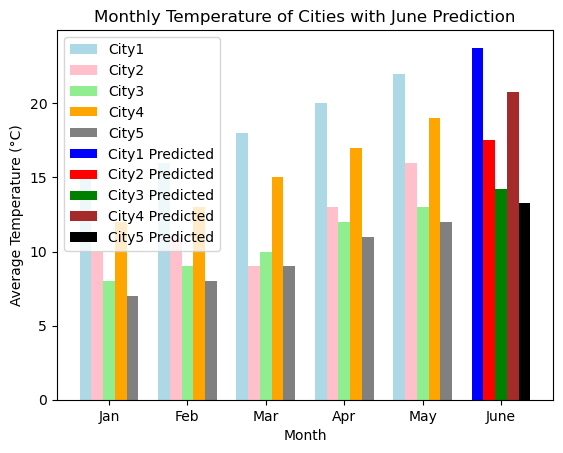

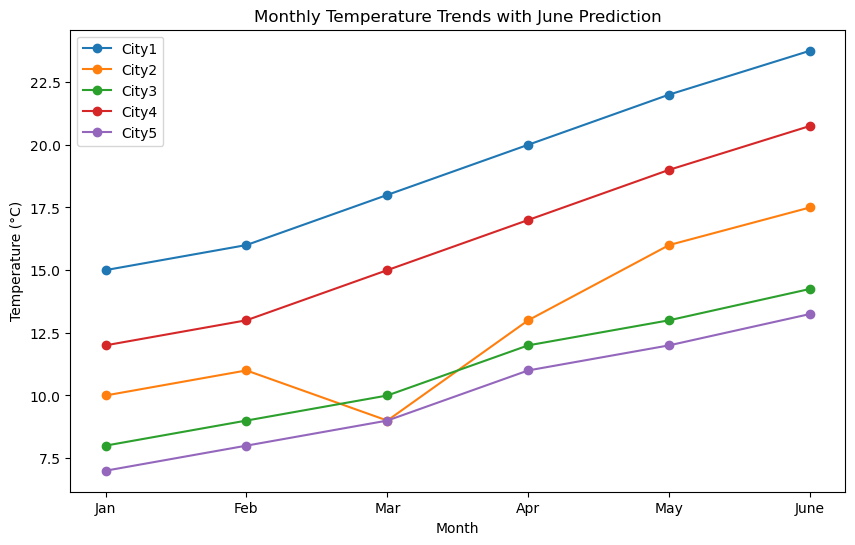

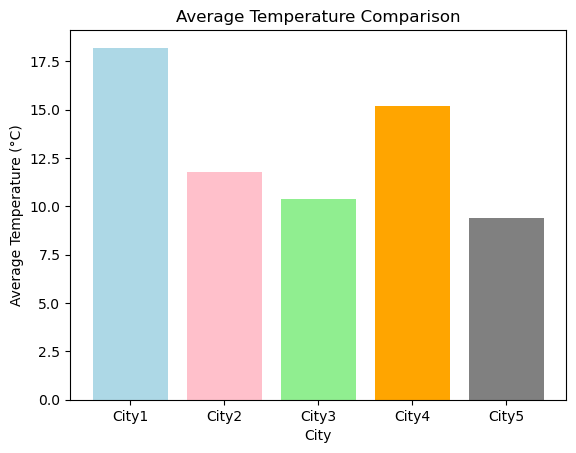

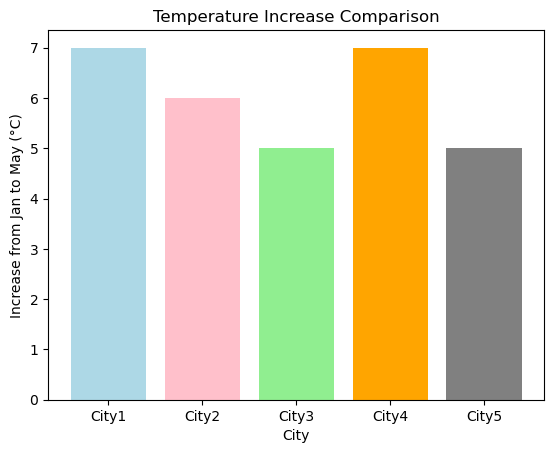

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Step 1: Load Excel file
# ============================================================
df = pd.read_excel("Weather_Analysis_Prediction.xlsx")
print("Monthly temperature dataset:\n", df)

# ============================================================
# Step 2: NumPy calculations and June prediction
# ============================================================
city_names = ['City1', 'City2', 'City3', 'City4', 'City5']
predicted = []

print("\n--- Statistics and Prediction ---")
for city in city_names:
    city_data = np.array([df[city][i] for i in range(5)])
    print(f"\n{city}:")
    print("Average:", np.mean(city_data))
    print("Min:", np.min(city_data))
    print("Max:", np.max(city_data))
    print("Std Dev:", np.std(city_data))
    # Predict June using linear trend
    slope = (city_data[4] - city_data[0]) / (5 - 1)
    next_month = city_data[4] + slope
    predicted.append(next_month)

print("\nPredicted temperatures for June:")
for i in range(len(city_names)):
    print(city_names[i], ":", round(predicted[i],1))

# ============================================================
# Step 3: Comparison between cities
# ============================================================
avg_temps = []
increase = []
for city in city_names:
    city_data = np.array([df[city][i] for i in range(5)])
    avg_temps.append(np.mean(city_data))
    increase.append(city_data[4]-city_data[0])

# Highest average
max_avg = max(avg_temps)
max_city = city_names[avg_temps.index(max_avg)]
print("\nCity with highest average temperature:", max_city, "with", round(max_avg,1))

# Highest increase
max_inc = max(increase)
max_inc_city = city_names[increase.index(max_inc)]
print("City with highest temperature increase from Jan to May:", max_inc_city, "with", max_inc)

# ============================================================
# Step 4: Bar plot including June prediction
# ============================================================
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June']
width = 0.15
n = len(df['Month'])
index = np.arange(n)

# Original months
plt.bar(index, [df['City1'][i] for i in range(5)], width, color='lightblue', label='City1')
plt.bar(index + width, [df['City2'][i] for i in range(5)], width, color='pink', label='City2')
plt.bar(index + width*2, [df['City3'][i] for i in range(5)], width, color='lightgreen', label='City3')
plt.bar(index + width*3, [df['City4'][i] for i in range(5)], width, color='orange', label='City4')
plt.bar(index + width*4, [df['City5'][i] for i in range(5)], width, color='grey', label='City5')

# Add predicted June values as last bars
plt.bar(5, predicted[0], width, color='blue', label='City1 Predicted')
plt.bar(5 + width, predicted[1], width, color='red', label='City2 Predicted')
plt.bar(5 + width*2, predicted[2], width, color='green', label='City3 Predicted')
plt.bar(5 + width*3, predicted[3], width, color='brown', label='City4 Predicted')
plt.bar(5 + width*4, predicted[4], width, color='black', label='City5 Predicted')

plt.xticks(np.arange(6) + width*2, months)
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.title('Monthly Temperature of Cities with June Prediction')
plt.legend()
plt.show()

# ============================================================
# Step 5: Line plots to show trends
# ============================================================
plt.figure(figsize=(10,6))
plt.plot(months[:5] + ['June'], [df['City1'][i] for i in range(5)] + [predicted[0]], marker='o', label='City1')
plt.plot(months[:5] + ['June'], [df['City2'][i] for i in range(5)] + [predicted[1]], marker='o', label='City2')
plt.plot(months[:5] + ['June'], [df['City3'][i] for i in range(5)] + [predicted[2]], marker='o', label='City3')
plt.plot(months[:5] + ['June'], [df['City4'][i] for i in range(5)] + [predicted[3]], marker='o', label='City4')
plt.plot(months[:5] + ['June'], [df['City5'][i] for i in range(5)] + [predicted[4]], marker='o', label='City5')

plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.title('Monthly Temperature Trends with June Prediction')
plt.legend()
plt.show()

# ============================================================
# Step 6: Bar plots for comparison of average and increase
# ============================================================
# Average comparison
plt.bar(city_names, avg_temps, color=['lightblue','pink','lightgreen','orange','grey'])
plt.xlabel('City')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature Comparison')
plt.show()

# Increase comparison
plt.bar(city_names, increase, color=['lightblue','pink','lightgreen','orange','grey'])
plt.xlabel('City')
plt.ylabel('Increase from Jan to May (°C)')
plt.title('Temperature Increase Comparison')
plt.show()
